In [19]:
import sys
sys.path.append("../utils/py")
import miniramses as ram

In [20]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import argparse
import miniramses as ram

plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 800
plt.rcParams.update({
    "font.size": 20,
    "legend.fontsize": 18,
})

prefix = 'grav'
path = '/home/jl4415/mini-ramses/'
nout = '4'

center = np.array([600, 600, 600])
log0 = None

if prefix is None:
    prefix = "hydro"
if path is None:
    path = "./"
else:
    path = path + "/"

if prefix == "hydro":
    isort = 0
if prefix == "peak":
    isort = 1
if prefix == "grav":
    isort = 0
if prefix == "rt":
    isort = 0

print("Reading output number", nout)


def amr_slice(c, cen, levels=None):
    """
    Select cells whose volume intersects the slice plane z = cen.
    Optionally filter by AMR level.
    """
    mask = np.abs(c.x[2] - cen) <= c.dx / 2

    if levels is not None:
        mask = mask & np.isin(c.level, levels)

    x = c.x[0][mask]
    y = c.x[1][mask]
    dx = c.dx[mask]

    return x, y, dx, mask


# -----------------------------
# PLOT SINGLE OUTPUT
# -----------------------------
def plot(nout, cen=600, levels=None, **visu_kwargs):
    """
    Plot one output.

    Parameters
    ----------
    nout : int or str
        Output number.
    cen : float
        Slice center in z.
    levels : sequence or None
        Optional AMR levels to keep.
    **visu_kwargs :
        Any keyword arguments forwarded to ram.visu(), e.g.
        grid=True, cmap="viridis", vmin=..., vmax=..., log=True, npix=...
    """
    print("Reading output", nout)

    c = ram.rd_cell(str(nout), path=path, prefix=prefix, center=center)
    i = ram.rd_info(str(nout), path=path)

    print("Available levels:", np.unique(c.level))

    x, y, dx, mask = amr_slice(c, cen, levels)

    val = c.g[0][mask]
    lev = c.level[mask]

    return ram.visu(x, y, dx, val, lev, **visu_kwargs)


# -----------------------------
# COMPARE TWO OUTPUTS
# -----------------------------
def compare(nout, nout_base, cen=600, levels=None, **visu_kwargs):
    """
    Compare two outputs by plotting their difference.

    Parameters
    ----------
    nout : int or str
        Output number to plot.
    nout_base : int or str
        Reference output number.
    cen : float
        Slice center in z.
    levels : sequence or None
        Optional AMR levels to keep.
    **visu_kwargs :
        Any keyword arguments forwarded to ram.visu().
    """
    print("Reading output", nout, "and base", nout_base)

    c = ram.rd_cell(str(nout), path=path, prefix=prefix, center=center)
    c_base = ram.rd_cell(str(nout_base), path=path, prefix=prefix, center=center)

    x, y, dx, mask = amr_slice(c, cen, levels)

    diff = c.g[0] - c_base.g[0]
    val = diff[mask]
    lev = c.level[mask]

    out = ram.visu(x, y, dx, val, lev, **visu_kwargs)

    denom = c_base.g[0][mask]
    good = denom != 0

    if np.any(good):
        rel = val[good] / denom[good]
        print("mean relative error:", np.mean(rel))
        print("median relative error:", np.median(rel))
    else:
        print("Relative error undefined: denominator is zero everywhere on the slice.")

    return out

Reading output number 4


In [21]:
#nout =  '3'  # fmm (7,8) ! pre-direct-multipole expansion
#nout =  '4'  # multgrid  (7,8)
#nout =  '5'  # multigrid (8,8)
#nout =  '6'  # fmm (8,8)
#nout =  '23'  # fmm (7,8,9) ! pre-direct-multipole expansion
#nout =  '24'  # multgrid  (7,8,9)

Reading output 2
ncpu=1 ndim=3 nlevelmax=10
Time= 0.0141353587100769
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 3464728 leaf cells
Extracting leaf cells...
Available levels: [7 8 9]
subset value range: -0.2595701515674591 -0.025040989741683006
image range: -0.2595701515674591 -0.025040989741683006
spatial box: [1.0, 3.0, 1.0, 3.0]


(<Figure size 1200x1200 with 2 Axes>,
 <AxesSubplot:>,
 <matplotlib.image.AxesImage at 0x14da05ebb700>)

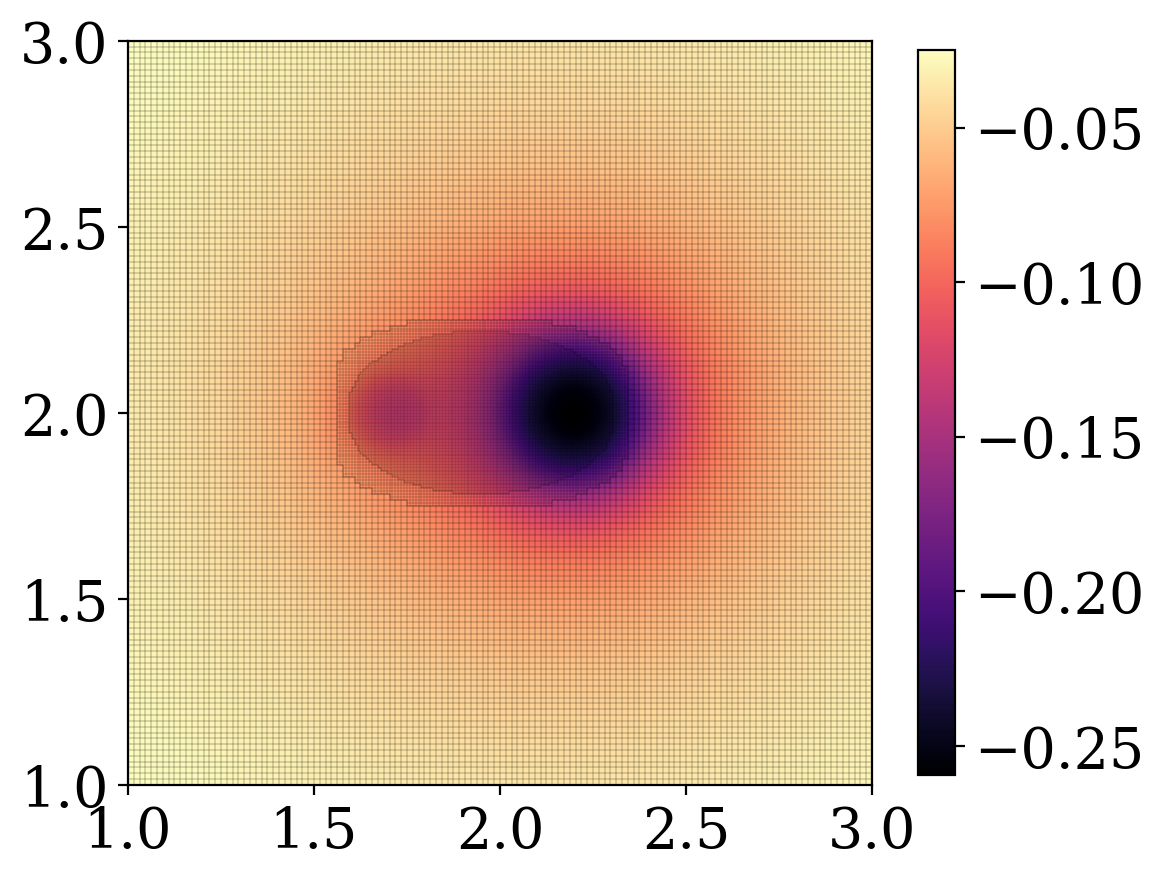

In [22]:
plot(2, 2.0, grid=True)

Reading output 24 and base 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
subset value range: -3277.7578125 58.9609375
image range: -3277.7578125 39.625
spatial box: [356.25, 834.375, 365.625, 834.375]
mean relative error: 0.004017512853322425
median relative error: 0.0037571818978789397


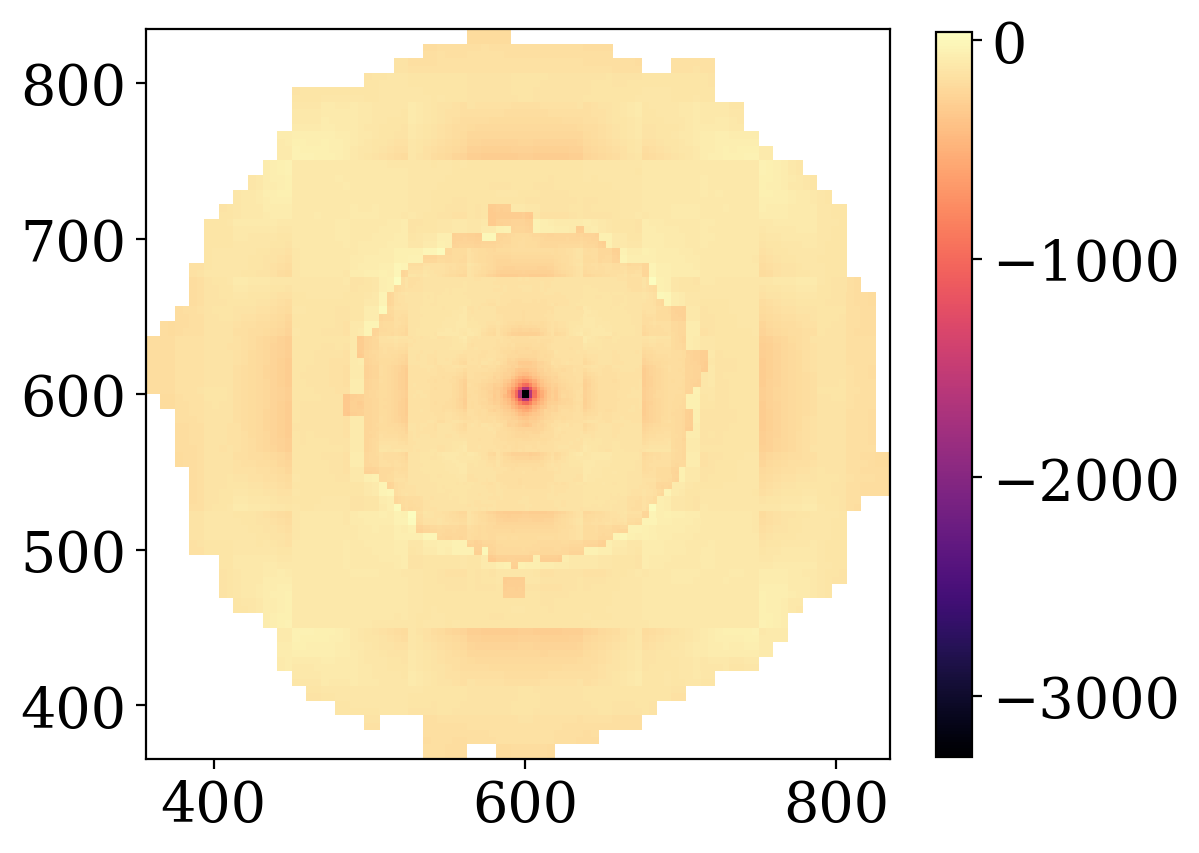

In [5]:
compare(24, 23, 600, levels=[7,8], grid=False)
plt.savefig("./fig/lev78.png")
#mk_image // project

Reading output 24 and base 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
subset value range: -3277.7578125 58.9609375
image range: -3277.7578125 39.625
spatial box: [300.0, 900.0, 300.0, 900.0]
mean relative error: 0.003992840508452441
median relative error: 0.0037402271830726244


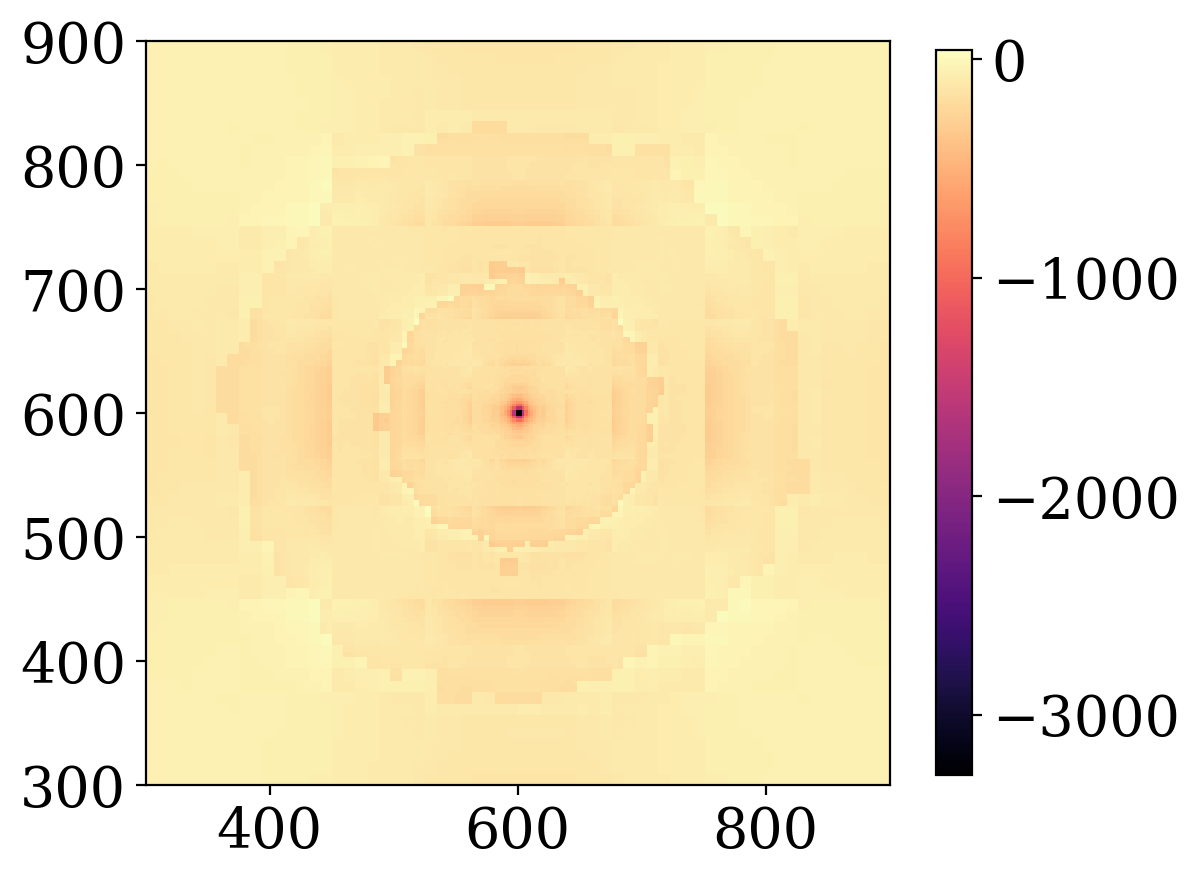

In [6]:
c = compare(24, 23, 600, grid=False, levels=[6,7,8])
plt.savefig("./fig/lev678.png")
#mk_image // project

Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
Available levels: [6 7 8]
subset value range: -130217.2109375 -37048.78125
image range: -130217.2109375 -37048.78125
spatial box: [300, 900, 300, 900]
Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
Available levels: [6 7 8]
subset value range: -44965.15234375 -22240.92578125
image range: -44965.15234375 -22240.92578125
spatial box: [300, 900, 300, 900]
Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 le

(<Figure size 1200x1200 with 2 Axes>,
 <AxesSubplot:>,
 <matplotlib.image.AxesImage at 0x14e633618af0>)

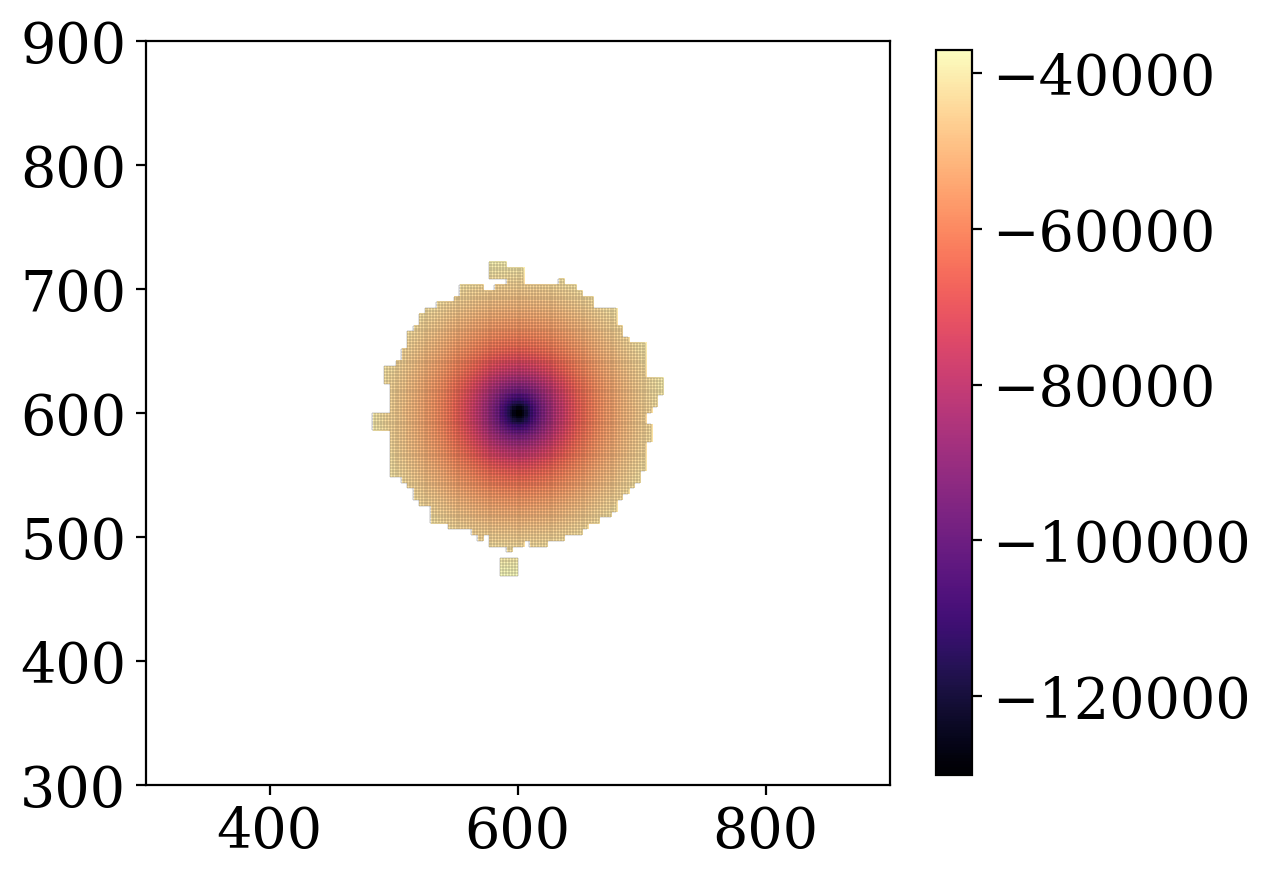

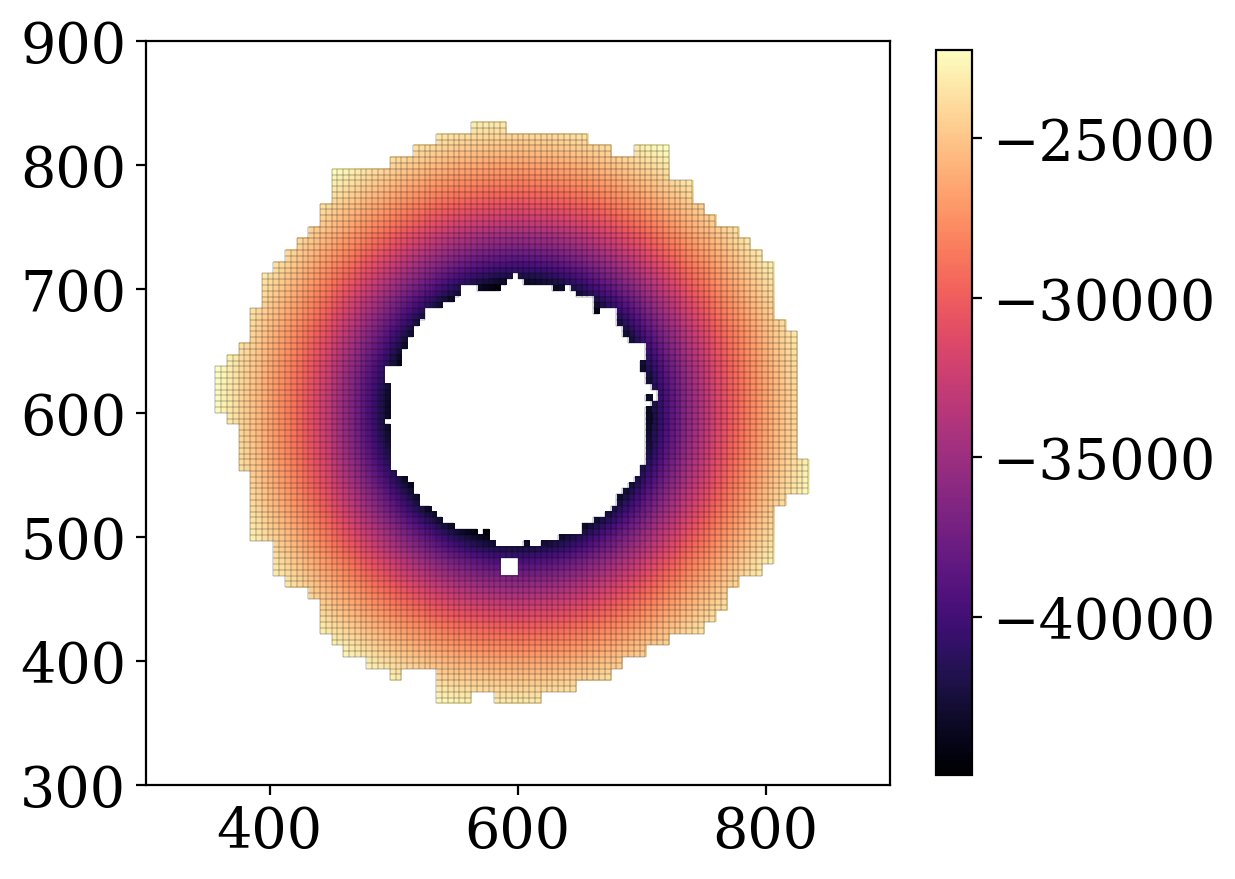

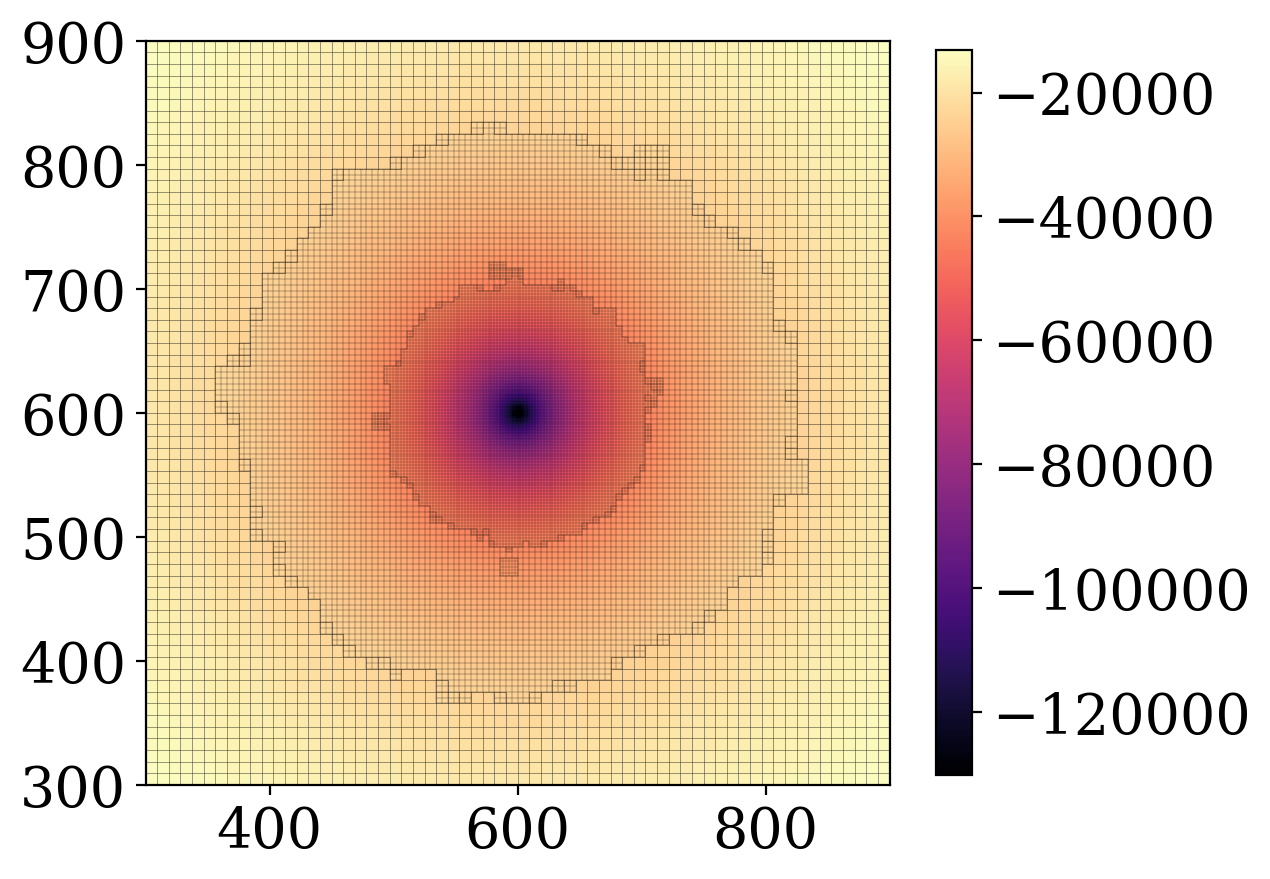

In [7]:
box = [300, 900, 300, 900]

plot(23, 600, grid=True, levels=[8], box=box)
plot(23, 600, grid=True, levels=[7], box=box)
plot(23, 600, grid=True, levels=[6, 7, 8], box=box)

In [ ]:
#mg
'''
     seconds         %    STEP
       0.127       1.0    refine                  
       2.844      21.4    rho                     
       7.502      56.4    poisson                 
       2.797      21.0    particle - kickdrift    
       0.030       0.2    time step               
      13.300     100.0    TOTAL
'''

In [ ]:
#fmm

'''
     seconds         %    STEP
       0.068       0.5    refine                  
       3.020      23.7    rho                     
       7.583      59.6    poisson                 
       0.108       0.9    grav force              
       1.896      14.9    particle - kickdrift    
       0.028       0.2    time step               
       0.017       0.1    recursive call          
      12.721     100.0    TOTAL
'''

In [ ]:
plot(13, 2, False)

In [ ]:
compare(13, 14, 2, True)

In [ ]:
plot(2, 600, False)